In [1]:
%load_ext autoreload
%autoreload 2

In [49]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt

import game_players_parser

from nba_api.stats.endpoints import playercareerstats

In [3]:
con = duckdb.connect(database='../data/nba.sqlite', read_only=False)
all_games_df = con.query("select * from game").fetchdf()

In [4]:
regular_games = (all_games_df['season_type'] == 'Regular Season') | (all_games_df['season_type'] == 'Playoffs')
game_info_df = all_games_df[regular_games]
game_info_df = game_info_df.dropna(subset="fga_home")
game_info_df['season_id'] = game_info_df['season_id'].astype(int)
game_info_df['year'] = game_info_df['season_id'] % 20000
game_info_df = game_info_df[game_info_df['year'] >= 2000]

predicting game 0020000013 at index 36046
no cached game found for 0020000013, fetching play by play


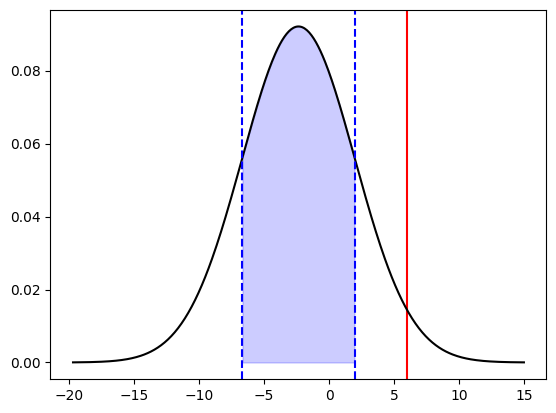

In [81]:
pct_samples = pd.read_csv('../results/general_pct_non_possession_posterior.csv')
att_samples = pd.read_csv('../results/general_attempt_non_possession_posterior.csv')

beta_labels = [f"beta[{i}]" for i in range(1, 11)]

pct_betas = pct_samples[beta_labels].mean().to_numpy()
pct_alpha = pct_samples['alpha'].mean()
pct_sigma = pct_samples['sigma'].mean()

att_betas = att_samples[beta_labels].mean().to_numpy()
att_alpha = att_samples['alpha'].mean()
att_sigma = att_samples['sigma'].mean()

# loop is set up to iterate over all rows eventually
# for now it breaks out of the loop after one game for testing
# 
ignored_games = [36041, 36042, 36043, 36044, 36045]
for index, row in game_info_df.iterrows():
    if index in ignored_games:
        continue

    game_id = row['game_id']
    print(f'predicting game {game_id} at index {index}')
    home_id = row['team_id_home']
    away_id = row['team_id_away']
    season = int(str(row['season_id'])[1:])
    aggregate_stats = game_players_parser.get_aggregate_stats_for_game(game_id, season)

    home_predicted = pct_alpha + np.sum(pct_betas * aggregate_stats['home_aggregate']['player_aggregate_pct'])
    away_predicted = pct_alpha + np.sum(pct_betas * aggregate_stats['away_aggregate']['player_aggregate_pct'])
    # mu = home_predicted - away_predicted
    mu = pct_alpha + np.sum(pct_betas * aggregate_stats['home_aggregate']['player_aggregate_pct']) - np.sum(pct_betas * aggregate_stats['away_aggregate']['player_aggregate_pct'])
    sigma = pct_sigma

    fig, ax = plt.subplots()
    ax.axvline(row['plus_minus_home'], color='red')
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    pdf = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2))
    ax.plot(x, pdf, color='black')
    ax.fill_between(x, pdf, 0, where=(x >= mu - sigma) & (x <= mu + sigma), color='blue', alpha=0.2)

    ax.axvline(mu - sigma, color='blue', linestyle='--')
    ax.axvline(mu + sigma, color='blue', linestyle='--')

    # for testing/development
    break